# Module A: Database Index Structure Implementation

## Introduction
This report documents the implementation and performance analysis of a lightweight Database Management System (DBMS) indexing engine. The primary objective is to compare the performance of a custom-built B+ Tree against a baseline Brute Force approach. 

The evaluation covers insertion, exact search, deletion, range queries, random mixed operations, and memory usage.

In [1]:
import time
import random
import tracemalloc
import matplotlib.pyplot as plt

# Import your implementations
from database.bplustree import BPlusTree
from database.table import Table
from database.db_manager import DatabaseManager
from database.bruteforce import BruteForceDB

# Set a random seed for reproducible results
random.seed(42)

In [2]:
import os
import time
import sys
import random
from statistics import mean
from decimal import Decimal
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [10]:
import time
import random
import sys
from decimal import Decimal
from datetime import datetime, timedelta
import matplotlib.pyplot as plt


class PerformanceAnalyzer:
    def __init__(self, dataset_sizes=None, trials=3, order=100, seed=42, key_domain=10_000_000):
        if dataset_sizes is None:
            self.dataset_sizes = [1000, 5000, 10000, 25000, 50000]
        else:
            self.dataset_sizes = dataset_sizes
            
        self.trials = trials
        self.order = order
        self.key_domain = key_domain
        self.rng = random.Random(seed)
        
        self.schema = {
            "customerID": int,
            "loyaltyTier": int,
            "membershipDiscount": int,
            "cartTotalAmount": float,
            "membershipDueDate": int,
            "membership": bool,
        }
        
        self.results = {
            "insert": {"bplustree": [], "bruteforce": []},
            "search": {"bplustree": [], "bruteforce": []},
            "range_query": {"bplustree": [], "bruteforce": []},
            "delete": {"bplustree": [], "bruteforce": []},
            "mixed_populated": {"bplustree": [], "bruteforce": []},
            "mixed_empty": {"bplustree": [], "bruteforce": []},
            "memory": {"bplustree": [], "bruteforce": []},
        }

    def _make_record(self, customer_id):
        return {
            "customerID": customer_id,
            "loyaltyTier": self.rng.randint(1, 5),
            "membershipDiscount": self.rng.randint(0, 100),
            "cartTotalAmount": self.rng.uniform(0, 100000),
            "membershipDueDate": self.rng.randint(0, 3650),
            "membership": self.rng.choice([True, False]),
        }

    def _generate_unique_keys(self, n):
        return self.rng.sample(range(1, self.key_domain), n)

    def _generate_absent_keys(self, n):
        base = self.key_domain + 1
        return self.rng.sample(range(base, base + self.key_domain), n)

    def _create_structures(self):
        table_bt = Table(
            name="Cust_BT",
            schema=self.schema, 
            order=self.order, 
            search_key="customerID", 
            index_type="bplustree"
        )
        table_bf = Table(
            name="Cust_BF", 
            schema=self.schema, 
            order=self.order, 
            search_key="customerID", 
            index_type="bruteforce"
        )
        return table_bt, table_bf

    def _estimate_memory(self, obj):
        seen = set()
        stack = [obj]
        total_size = 0
        while stack:
            o = stack.pop()
            oid = id(o)
            if oid in seen: continue
            seen.add(oid)
            total_size += sys.getsizeof(o)
            if isinstance(o, dict):
                for k, v in o.items():
                    stack.append(k)
                    stack.append(v)
            elif isinstance(o, (list, tuple, set, frozenset)):
                for item in o:
                    stack.append(item)
            elif hasattr(o, "__dict__"):
                stack.append(vars(o))
        return total_size

    def _benchmark_insert(self, keys, records):
        table_bt, table_bf = self._create_structures()

        start = time.perf_counter()
        for key in keys:
            table_bt.insert(records[key])
        bplus_time = time.perf_counter() - start

        start = time.perf_counter()
        for key in keys:
            table_bf.insert(records[key])
        brute_time = time.perf_counter() - start

        return bplus_time, brute_time

    def _benchmark_search(self, keys, records):
        table_bt, table_bf = self._create_structures()
        n = len(keys)
        
        for key in keys:
            table_bt.insert(records[key])
            table_bf.insert(records[key])

        num_queries = max(10, n // 10)
        present_queries = self.rng.sample(keys, num_queries // 2)
        absent_queries = self._generate_absent_keys(num_queries - len(present_queries))
        queries = present_queries + absent_queries
        self.rng.shuffle(queries)

        start = time.perf_counter()
        for q in queries:
            table_bt.get(q)
        bplus_time = time.perf_counter() - start

        start = time.perf_counter()
        for q in queries:
            table_bf.get(q)
        brute_time = time.perf_counter() - start

        return bplus_time, brute_time

    def _benchmark_range_query(self, keys, records):
        table_bt, table_bf = self._create_structures()
        n = len(keys)
        
        for key in keys:
            table_bt.insert(records[key])
            table_bf.insert(records[key])

        num_queries = max(10, n // 20)
        width = self.key_domain // 1000 
        queries = [(left, left + self.rng.randint(0, width)) for left in [self.rng.randint(1, self.key_domain - width - 1) for _ in range(num_queries)]]

        start = time.perf_counter()
        for left, right in queries:
            table_bt.range_query(left, right)
        bplus_time = time.perf_counter() - start

        start = time.perf_counter()
        for left, right in queries:
            table_bf.range_query(left, right)
        brute_time = time.perf_counter() - start

        return bplus_time, brute_time

    def _benchmark_delete(self, keys, records):
        table_bt, table_bf = self._create_structures()
        n = len(keys)
        
        for key in keys:
            table_bt.insert(records[key])
            table_bf.insert(records[key])

        num_to_delete = max(10, n // 10)
        delete_keys = self.rng.sample(keys, num_to_delete)

        start = time.perf_counter()
        for key in delete_keys:
            table_bt.delete(key)
        bplus_time = time.perf_counter() - start

        start = time.perf_counter()
        for key in delete_keys:
            table_bf.delete(key)
        brute_time = time.perf_counter() - start

        return bplus_time, brute_time

    def _generate_mixed_ops(self, initial_pool, num_ops, is_empty_start=False):
        available = list(initial_pool)
        present = []
        operations = []

        for _ in range(num_ops):
            if is_empty_start and len(present) < (num_ops // 4):
                op = "insert"
            else:
                op = self.rng.choice(["insert", "search", "delete"])
            
            if op == "insert" and not available: op = "search" if present else "delete"
            if op == "delete" and not present: op = "insert" if available else "search"
            
            if op == "insert":
                key = available.pop()
                present.append(key)
                operations.append(("insert", key, self._make_record(key)))
            elif op == "search":
                key = self.rng.choice(present) if (present and self.rng.random() < 0.7) else (self.rng.choice(available) if available else self.rng.choice(present))
                operations.append(("search", key, None))
            elif op == "delete":
                key = present.pop(self.rng.randrange(len(present)))
                operations.append(("delete", key, None))
                
        return operations

    def _benchmark_mixed_populated(self, keys, records):
        table_bt, table_bf = self._create_structures()
        n = len(keys)
        
        for key in keys:
            table_bt.insert(records[key])
            table_bf.insert(records[key])
            
        extra_keys = self._generate_unique_keys(n) 
        operations = self._generate_mixed_ops(extra_keys, max(10, n // 2), is_empty_start=False)

        start = time.perf_counter()
        for op, key, record in operations:
            if op == "insert": table_bt.insert(record)
            elif op == "search": table_bt.get(key)
            elif op == "delete": table_bt.delete(key)
        bplus_time = time.perf_counter() - start

        start = time.perf_counter()
        for op, key, record in operations:
            if op == "insert": table_bf.insert(record)
            elif op == "search": table_bf.get(key)
            elif op == "delete": table_bf.delete(key)
        brute_time = time.perf_counter() - start

        return bplus_time, brute_time

    def _benchmark_mixed_empty(self, n):
        table_bt, table_bf = self._create_structures()
        
        pool = self._generate_unique_keys(n * 2)
        operations = self._generate_mixed_ops(pool, n, is_empty_start=True)

        start = time.perf_counter()
        for op, key, record in operations:
            if op == "insert": table_bt.insert(record)
            elif op == "search": table_bt.get(key)
            elif op == "delete": table_bt.delete(key)
        bplus_time = time.perf_counter() - start

        start = time.perf_counter()
        for op, key, record in operations:
            if op == "insert": table_bf.insert(record)
            elif op == "search": table_bf.get(key)
            elif op == "delete": table_bf.delete(key)
        brute_time = time.perf_counter() - start

        return bplus_time, brute_time

    def _benchmark_memory(self, keys, records):
        table_bt, table_bf = self._create_structures()

        for key in keys:
            table_bt.insert(records[key])
            table_bf.insert(records[key])

        bplus_mem = self._estimate_memory(table_bt.data)
        brute_mem = self._estimate_memory(table_bf.data)

        return bplus_mem, brute_mem

    def _plot_operation(self, ax_linear, ax_log, op_name, ylabel, title, memory=False):
        x = self.dataset_sizes
        if memory:
            # Convert bytes to KB
            y1 = [max(v / 1024, 1e-7) for v in self.results[op_name]["bplustree"]]
            y2 = [max(v / 1024, 1e-7) for v in self.results[op_name]["bruteforce"]]
            ylabel = "Memory (KB)"
        else:
            y1 = [max(v, 1e-7) for v in self.results[op_name]["bplustree"]]
            y2 = [max(v, 1e-7) for v in self.results[op_name]["bruteforce"]]

        # --- Linear Plot ---
        ax_linear.plot(x, y1, marker="o", label="B+ Tree Index")
        ax_linear.plot(x, y2, marker="s", label="Brute Force Index")
        ax_linear.set_xlabel("Dataset size (n)")
        ax_linear.set_ylabel(ylabel)
        ax_linear.set_title(f"{title} (Linear Scale)")
        ax_linear.grid(True, alpha=0.3)
        ax_linear.legend()

        # --- Log Plot ---
        ax_log.plot(x, y1, marker="o", label="B+ Tree Index")
        ax_log.plot(x, y2, marker="s", label="Brute Force Index")
        ax_log.set_xlabel("Dataset size (n)")
        ax_log.set_ylabel(ylabel)
        ax_log.set_title(f"{title} (Log Scale)")
        ax_log.set_yscale('log')
        ax_log.grid(True, alpha=0.3)
        ax_log.legend()

    def run_all(self):
        for n in self.dataset_sizes:
            insert_bt, insert_bf = [], []
            search_bt, search_bf = [], []
            range_bt, range_bf = [], []
            delete_bt, delete_bf = [], []
            mix_pop_bt, mix_pop_bf = [], []
            mix_emp_bt, mix_emp_bf = [], []
            memory_bt, memory_bf = [], []

            for _ in range(self.trials):
                keys = self._generate_unique_keys(n)
                records = {key: self._make_record(key) for key in keys}

                t1, t2 = self._benchmark_insert(keys, records)
                insert_bt.append(t1); insert_bf.append(t2)

                t1, t2 = self._benchmark_search(keys, records)
                search_bt.append(t1); search_bf.append(t2)
                
                t1, t2 = self._benchmark_range_query(keys, records)
                range_bt.append(t1); range_bf.append(t2)
                
                t1, t2 = self._benchmark_delete(keys, records)
                delete_bt.append(t1); delete_bf.append(t2)
                
                t1, t2 = self._benchmark_mixed_populated(keys, records)
                mix_pop_bt.append(t1); mix_pop_bf.append(t2)
                
                t1, t2 = self._benchmark_mixed_empty(n)
                mix_emp_bt.append(t1); mix_emp_bf.append(t2)
                
                m1, m2 = self._benchmark_memory(keys, records)
                memory_bt.append(m1); memory_bf.append(m2)

            self.results["insert"]["bplustree"].append(sum(insert_bt) / self.trials)
            self.results["insert"]["bruteforce"].append(sum(insert_bf) / self.trials)
            
            self.results["search"]["bplustree"].append(sum(search_bt) / self.trials)
            self.results["search"]["bruteforce"].append(sum(search_bf) / self.trials)
            
            self.results["range_query"]["bplustree"].append(sum(range_bt) / self.trials)
            self.results["range_query"]["bruteforce"].append(sum(range_bf) / self.trials)
            
            self.results["delete"]["bplustree"].append(sum(delete_bt) / self.trials)
            self.results["delete"]["bruteforce"].append(sum(delete_bf) / self.trials)
            
            self.results["mixed_populated"]["bplustree"].append(sum(mix_pop_bt) / self.trials)
            self.results["mixed_populated"]["bruteforce"].append(sum(mix_pop_bf) / self.trials)
            
            self.results["mixed_empty"]["bplustree"].append(sum(mix_emp_bt) / self.trials)
            self.results["mixed_empty"]["bruteforce"].append(sum(mix_emp_bf) / self.trials)
            
            self.results["memory"]["bplustree"].append(sum(memory_bt) / self.trials)
            self.results["memory"]["bruteforce"].append(sum(memory_bf) / self.trials)

        # ---------------------------------------------------------
        # 1. Print Speedup & Memory Statistics to Console (COLUMN FORMAT)
        # ---------------------------------------------------------
        print("\n" + "="*80)
        print(f"{'PERFORMANCE SUMMARY: B+ TREE vs BRUTE FORCE':^80}")
        print("="*80)
        
        for i, n in enumerate(self.dataset_sizes):
            print(f"\n--- DATASET SIZE: {n:,} RECORDS ---")
            print(f"{'Operation':<18} | {'B+ Tree':<15} | {'Brute Force':<15} | {'Speedup / Space'}")
            print("-" * 80)
            
            # Print Time Metrics
            ops = ["insert", "search", "range_query", "delete", "mixed_populated", "mixed_empty"]
            for op in ops:
                bt_time = max(self.results[op]["bplustree"][i], 1e-9) 
                bf_time = self.results[op]["bruteforce"][i]
                speedup = bf_time / bt_time
                
                print(f"{op:<18} | {bt_time:>11.5f} s   | {bf_time:>11.5f} s   | {speedup:>10.2f}x faster")
            
            # Print Memory Metrics
            bt_mem_kb = self.results["memory"]["bplustree"][i] / 1024
            bf_mem_kb = max(self.results["memory"]["bruteforce"][i] / 1024, 1e-9)
            mem_ratio = bt_mem_kb / bf_mem_kb
            
            print(f"{'memory':<18} | {bt_mem_kb:>11.2f} KB  | {bf_mem_kb:>11.2f} KB  | {mem_ratio:>10.2f}x space")


        # ---------------------------------------------------------
        # 2. Plot the 7x2 Grid (Linear and Log side-by-side)
        # ---------------------------------------------------------
        fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(16, 30))
        
        self._plot_operation(axes[0,0], axes[0,1], "insert", "Time (s)", "Insert Performance")
        self._plot_operation(axes[1,0], axes[1,1], "search", "Time (s)", "Search Performance")
        self._plot_operation(axes[2,0], axes[2,1], "range_query", "Time (s)", "Range Query")
        self._plot_operation(axes[3,0], axes[3,1], "delete", "Time (s)", "Delete Performance")
        self._plot_operation(axes[4,0], axes[4,1], "mixed_populated", "Time (s)", "Mixed Ops (Populated)")
        self._plot_operation(axes[5,0], axes[5,1], "mixed_empty", "Time (s)", "Mixed Ops (Empty Start)")
        self._plot_operation(axes[6,0], axes[6,1], "memory", "Memory (KB)", "Memory Consumption", memory=True)

        plt.tight_layout()
        plt.show()



                  PERFORMANCE SUMMARY: B+ TREE vs BRUTE FORCE                   

--- DATASET SIZE: 100 RECORDS ---
Operation          | B+ Tree         | Brute Force     | Speedup / Space
--------------------------------------------------------------------------------
insert             |     0.00029 s   |     0.00334 s   |      11.65x faster
search             |     0.00001 s   |     0.00002 s   |       3.03x faster
range_query        |     0.00001 s   |     0.00005 s   |       6.45x faster
delete             |     0.00002 s   |     0.00003 s   |       1.33x faster
mixed_populated    |     0.00008 s   |     0.00024 s   |       3.15x faster
mixed_empty        |     0.00016 s   |     0.00018 s   |       1.18x faster
memory             |        8.60 KB  |        7.49 KB  |       1.15x space

--- DATASET SIZE: 500 RECORDS ---
Operation          | B+ Tree         | Brute Force     | Speedup / Space
--------------------------------------------------------------------------------
insert   

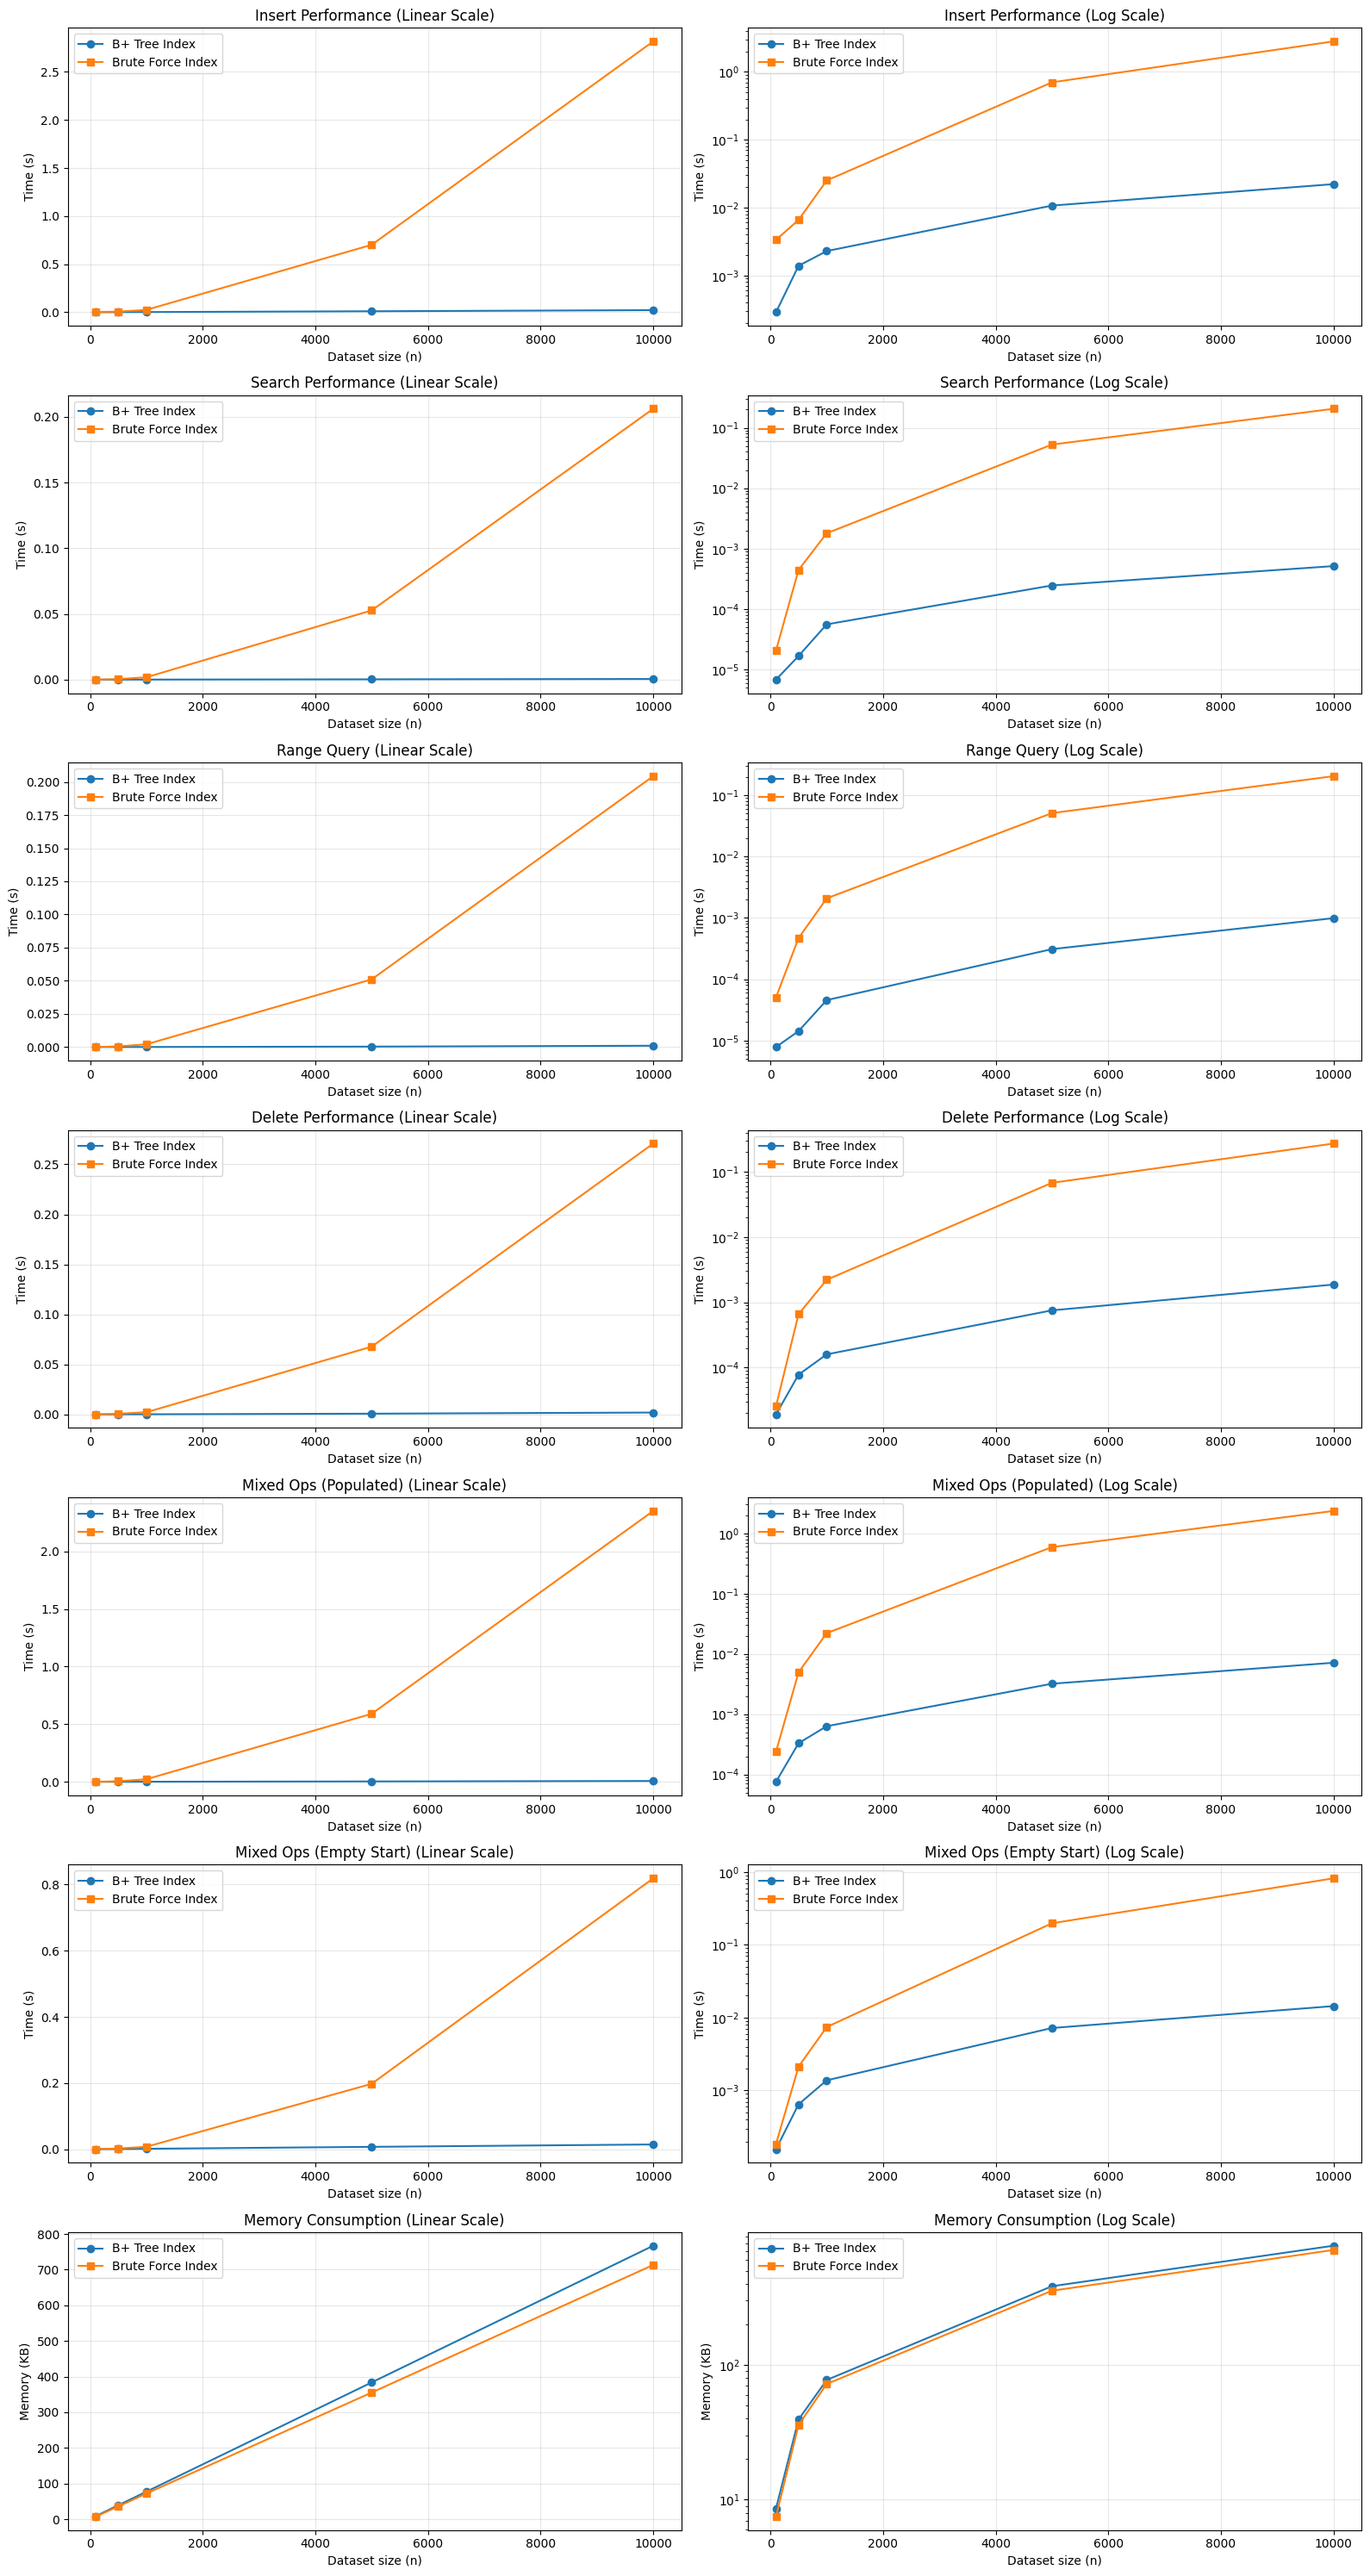

In [13]:
if __name__ == "__main__":
    analyzer = PerformanceAnalyzer(dataset_sizes=[100, 500, 1000,5000,10000], trials=1)
    analyzer.run_all()